In [1]:
# 1. Imports and configuration
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.tensorboard import SummaryWriter

sns.set(font_scale=1.4)
sns.set_style("white")
plt.rc("font", size=14)

# Reproducibility
SEED = 29
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

print(f"Device: {device}")

# ImageNet stats for EfficientNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training config
IMG_SIZE = 256
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 1000
PATIENCE = 30

print("Configuration")
print(f"  Image size: {IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Patience: {PATIENCE}")
print(f"  Max epochs: {EPOCHS}")

# Paths – adjust to your structure
PATH = "/kaggle/input/merged-dataset/"
TRAIN_IMG_DIR = "/kaggle/input/merged-dataset" #+ "train_data_cleaned/images"   # contains img_0001.png, ...
#TRAIN_MASK_DIR = PATH + "train_data_cleaned/masks"   # contains mask_0001.png, ...
TEST_IMG_DIR = "/kaggle/input/final-test2"     # contains img_XXXX.png
TRAIN_LABELS_CSV = PATH + "train_label.csv" # mapping image name to class label
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

import tifffile as tiff
from PIL import Image

2025-12-07 18:31:06.376404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765132266.397248     142 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765132266.403582     142 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Device: cuda
Configuration
  Image size: 256
  Batch size: 64
  Learning rate: 0.001
  Patience: 30
  Max epochs: 1000


In [2]:
!pip install lion-pytorch


In [3]:
# 2. Utility functions
# ============================================================

def mask_to_bbox(mask: np.ndarray):
    """
    From a single channel mask compute tight bounding box.

    Args:
        mask: 2D numpy array, non zero pixels are foreground

    Returns:
        (x1, y1, x2, y2) in absolute pixel coordinates
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        # fall back to full image if mask empty
        h, w = mask.shape
        return 0, 0, w - 1, h - 1
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return x1, y1, x2, y2


def spearman_rho(predictions, targets):
    """
    Spearman rank correlation between two vectors.

    Predictions and targets can be numpy arrays or tensors.
    Computed over flattened coordinates.
    """
    if isinstance(predictions, np.ndarray):
        predictions = torch.from_numpy(predictions)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)

    predictions = predictions.float().flatten()
    targets = targets.float().flatten()

    def rank(x):
        sorted_indices = torch.argsort(x)
        ranks = torch.argsort(sorted_indices) + 1
        return ranks.float()

    r_pred = rank(predictions)
    r_tgt = rank(targets)

    diff_pred = r_pred - r_pred.mean()
    diff_tgt = r_tgt - r_tgt.mean()

    cov = (diff_pred * diff_tgt).mean()
    std_pred = torch.sqrt((diff_pred ** 2).mean())
    std_tgt = torch.sqrt((diff_tgt ** 2).mean())

    return cov / (std_pred * std_tgt + 1e-8)

In [4]:
# 3. Data loading – localisation from masks
# ============================================================

def load_localisation_data(img_dir, img_dim):
    """
    Load images and corresponding masks, compute bounding boxes.

    Assumes:
      - image files named like img_0001.png
      - mask files named like mask_0001.png
    """
#CHANGED
    image_files = sorted(
        [f for f in os.listdir(img_dir) if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))]
    )

    images = []
    boxes = []

    for fname in image_files:
        img_path = os.path.join(img_dir, fname)
                # Read image with PIL (supports TIFF)
        try:
            img = Image.open(img_path)

            # If multi-page TIFF, take first page
            if getattr(img, "n_frames", 1) > 1:
                img.seek(0)

            img = np.array(img)

        except Exception as e:
            print(f"Skipping {fname}, cannot read TIFF: {e}")
            continue


        # Ensure 4 channels
        if img.ndim == 2:  # grayscale only → replicate + dummy mask
            img = np.stack([img]*3 + [np.zeros_like(img)], axis=-1)
            print("ndim  = 2!!!")
        elif img.shape[-1] == 3:  # RGB only → append dummy mask
            mask_channel = np.zeros_like(img[:, :, 0])
            img = np.dstack([img, mask_channel])
            print("only RGB!!!")
        elif img.shape[-1] == 4:  # RGBA → keep all 4 channels
            img = img[:, :, :4]
        else:
            # unexpected channels → pad/crop to 4
            print("channels fucked up")
            h, w = img.shape[:2]
            tmp = np.zeros((h, w, 4), dtype=img.dtype)
            tmp[:, :, :img.shape[-1]] = img
            img = tmp
            
        # img = tiff.imread(img_path)
        # if img is None:
        #     continue
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_dim, img_dim))

        mask = img[:, :, 3]

        # --- compute bounding box from mask ---
        ys, xs = np.where(mask > 0)

        if len(xs) == 0:
            # no mask foreground → no tumour → box = zeros
            x1 = y1 = x2 = y2 = 0.0
        else:
            x1 = xs.min() / img_dim
            x2 = xs.max() / img_dim
            y1 = ys.min() / img_dim
            y2 = ys.max() / img_dim

        bbox = [x1, y1, x2, y2]

        images.append(img)
        boxes.append(bbox)

    images = np.array(images)
    boxes = np.array(boxes, dtype=np.float32)

    print(f"Localisation data loaded: {len(images)} images")
    print(f"Image shape: {images[0].shape}")
    return images, boxes


X_loc, y_boxes = load_localisation_data(TRAIN_IMG_DIR, IMG_SIZE)

Localisation data loaded: 1239 images
Image shape: (256, 256, 4)


In [5]:
import pandas as pd
import os

# Path to your CSV and image folder
csv_path = TRAIN_LABELS_CSV
img_dir = TRAIN_IMG_DIR

# Read CSV
df = pd.read_csv(csv_path)

# Rewrite filenames: change .png to .tif
def fix_filename(fname):
    base, ext = os.path.splitext(fname)
    return base + ".tif"  # or ".tiff" if your files use that

df['sample_index'] = df['sample_index'].apply(fix_filename)

# Optional: check first few rows
print(df.head())

# Save back to CSV (overwrite or new file)
fixed_csv_path = "train_labels_fixed.csv"
df.to_csv(fixed_csv_path, index=False)

print(f"Fixed CSV saved to {fixed_csv_path}")


     sample_index            label
0  image_0000.tif  Triple negative
1  image_0001.tif        Luminal A
2  image_0002.tif        Luminal A
3  image_0003.tif        Luminal B
4  image_0004.tif          HER2(+)
Fixed CSV saved to train_labels_fixed.csv


In [6]:
# 4. Data loading – classification from CSV
# ============================================================

from sklearn.preprocessing import LabelEncoder

def load_classification_data(img_dir, labels_csv, img_dim,
                             img_col='sample_index',
                             label_col='label'):
    """
    Load images and string labels from a CSV.

    Returns:
        X: np.array of images (N, H, W, C)
        y: np.array of string labels (N,)
    """
    df = pd.read_csv(labels_csv)

    images = []
    labels = []

    for _, row in df.iterrows():
        fname = str(row[img_col])
        label = str(row[label_col])    # keep as string
        # --- Adjust filename inside the loop ---
        base, ext = os.path.splitext(fname)
        # change to actual extension of your images
        fname_fixed = base + ".tiff"  
    
        img_path = os.path.join(img_dir, fname_fixed)
        try:
            img = Image.open(img_path)

            # If multi-page TIFF, take the first page
            if getattr(img, "n_frames", 1) > 1:
                img.seek(0)

            img = np.array(img)

        except Exception as e:
            print(f"Skipping {fname}, cannot read TIFF: {e}")
            continue

        # Ensure 4 channels (RGB + mask)
        if img.ndim == 2:  # grayscale → replicate + dummy mask
            img = np.stack([img]*3 + [np.zeros_like(img)], axis=-1)
            print("ndim  = 2!!!")

        elif img.shape[-1] == 3:  # RGB only → append dummy mask
            mask_channel = np.zeros_like(img[:, :, 0])
            img = np.dstack([img, mask_channel])
            print("ndim  = 3!!!")

        elif img.shape[-1] == 4:  # RGBA → keep first 4 channels
            img = img[:, :, :4]
        else:
            # Unexpected channel number → pad/crop to 4
            print("ndim  = 5!!!")

            h, w = img.shape[:2]
            tmp = np.zeros((h, w, 4), dtype=img.dtype)
            tmp[:, :, :img.shape[-1]] = img
            img = tmp

        # center crop to square
        dim = min(img.shape[:-1])
        img = img[(img.shape[0]-dim)//2:(img.shape[0]+dim)//2,
                  (img.shape[1]-dim)//2:(img.shape[1]+dim)//2]
        img = cv2.resize(img, (img_dim, img_dim), interpolation=cv2.INTER_AREA)
        #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)


# Load classification data as images + string labels
X_cls, y_cls = load_classification_data(TRAIN_IMG_DIR, TRAIN_LABELS_CSV, IMG_SIZE)

# Encode string labels to integers
label_encoder = LabelEncoder()
y_cls_encoded = label_encoder.fit_transform(y_cls)

# number of classes and mapping int -> name
num_classes = len(label_encoder.classes_)
class_names = list(label_encoder.classes_)  # e.g. ["HER2(+)", "Luminal A", ...]
print("Classes:", class_names)

Classes: ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']


In [7]:
from sklearn.preprocessing import LabelEncoder

# y_cls are strings like 'Triple negative', 'Luminal A', etc.
label_encoder = LabelEncoder()
y_cls_int = label_encoder.fit_transform(y_cls)   # shape (N,)

# numeric label -> name mapping
num_to_labels = {i: lab for i, lab in enumerate(label_encoder.classes_)}

print("Classes:", num_to_labels)

Classes: {0: 'HER2(+)', 1: 'Luminal A', 2: 'Luminal B', 3: 'Triple negative'}


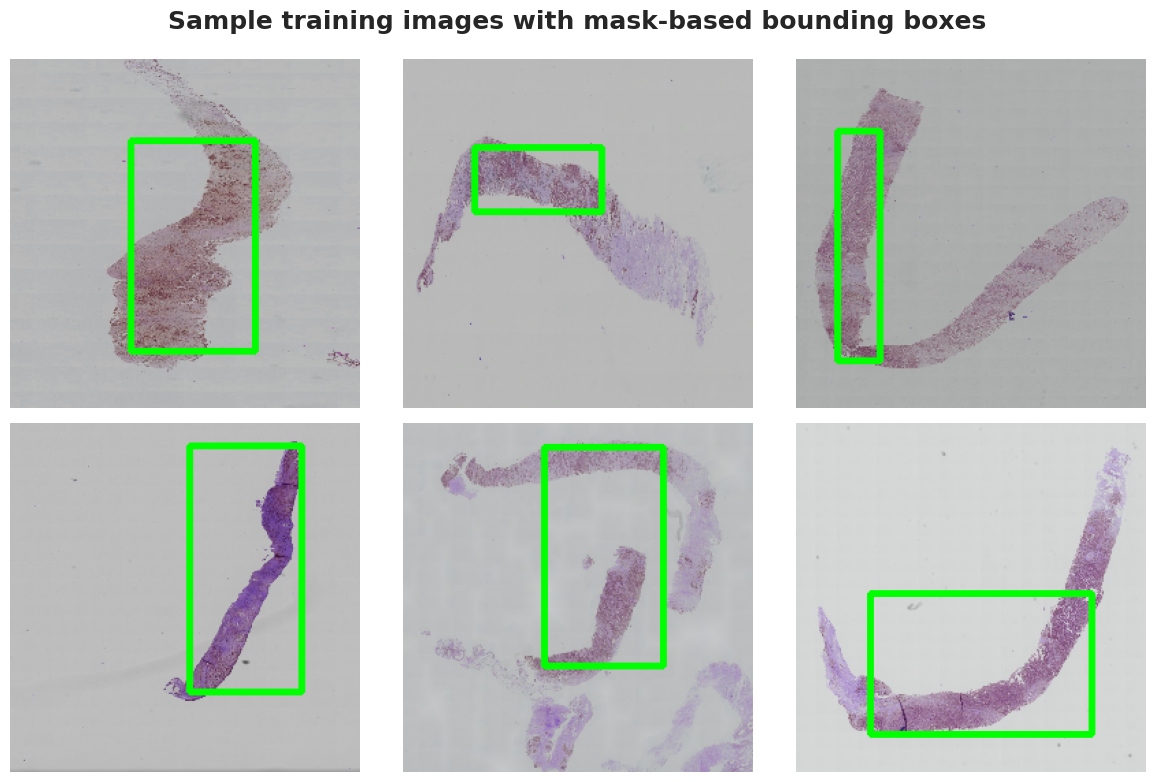

In [8]:
def visualize_samples_with_boxes(images, num_samples=6):
    """
    Visualize RGB + mask images with bounding boxes computed from channel 4
    """
    num_samples = min(num_samples, len(images))
    indices = np.random.choice(len(images), num_samples, replace=False)

    rows = 2
    cols = (num_samples + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Sample training images with mask-based bounding boxes",
                 fontsize=18, fontweight="bold")

    for i, idx in enumerate(indices):
        ax = axes[i]
        img = images[idx].copy()
        h, w, _ = img.shape

        # Extract mask from 4th channel
        mask = img[:, :, 3]

        # Compute bounding box from mask
        ys, xs = np.where(mask > 0)
        if len(xs) == 0 or len(ys) == 0:
            x1, y1, x2, y2 = 0, 0, 0, 0
        else:
            x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()

        # Draw rectangle on RGB only
        img_to_draw = img[:, :, :3].copy()
        if img_to_draw.dtype != np.uint8:
            img_to_draw = np.clip(img_to_draw, 0, 255).astype(np.uint8)

        cv2.rectangle(img_to_draw, (x1, y1), (x2, y2), (0, 255, 0), 3)
        ax.imshow(img_to_draw)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_samples_with_boxes(X_loc, num_samples=6)

In [9]:
import torchvision.transforms as T

normalize_rgb = T.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])

def normalize_4ch(img_tensor):
    # img_tensor shape: (C, H, W), C=4
    rgb = img_tensor[:3, :, :]/ 255.0 
    mask = img_tensor[3:, :, :]
    rgb = normalize_rgb(rgb)
    return torch.cat([rgb, mask], dim=0)


In [10]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1,2,3])  # LumA, LumB, HER2, TNBC
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_cls_int  # array of encoded labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion_cls = nn.CrossEntropyLoss(weight=class_weights)


In [11]:
# Multitask model
# -------------------------
class MultiTaskModel(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        # modify first conv to accept 4 channels
        old_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(4, old_conv.out_channels, old_conv.kernel_size,
                             old_conv.stride, old_conv.padding,
                             bias=old_conv.bias is not None)
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            new_conv.weight[:, 3:4, :, :] = 0.0
        self.backbone.features[0][0] = new_conv

        # freeze backbone if needed
        for p in self.backbone.parameters():
            p.requires_grad = True

        in_features = self.backbone.classifier[1].in_features
        # separate heads
        self.cls_head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )
        self.box_head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 4)
        )

    def forward(self, x):
        feat = self.backbone.features(x)
        feat = self.backbone.avgpool(feat)
        feat = torch.flatten(feat, 1)
        return self.cls_head(feat), self.box_head(feat)


# -------------------------
# MultiTask Dataset
# -------------------------
class MultiTaskDataset(Dataset):
    def __init__(self, images, labels, boxes, augmentation=None):
        self.images = torch.from_numpy(images).float().permute(0,3,1,2)
        self.labels = torch.from_numpy(labels).long()
        self.boxes = torch.from_numpy(boxes).float()
        self.augmentation = augmentation
        self.normalize_rgb = T.Normalize(mean=[0.485,0.456,0.406],
                                         std=[0.229,0.224,0.225])

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        lbl = self.labels[idx].clone()
        box = self.boxes[idx].clone()
        # normalization
        rgb = img[:3,:,:]
        mask = img[3:,:,:]
        rgb = self.normalize_rgb(rgb)
        img = torch.cat([rgb, mask], dim=0)
        return img, lbl, box

    def __len__(self):
        return len(self.images)


In [12]:
import torch.nn.functional as F

def train_multitask_epoch(model, loader, criterion_cls, bbox_weights, optimizer, scaler, lambda_box=1.0):
    model.train()
    loss_sum = 0.0
    accs = []
    for img, lbl, box in loader:
        img = img.to(device)
        lbl = lbl.to(device)
        box = box.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type=="cuda")):
            logits, pred_boxes = model(img)
            # classification loss (weighted CE passed as criterion_cls)
            loss_cls = criterion_cls(logits, lbl)

            # bbox loss (Smooth L1 per-element)
            loss_bbox_raw = F.smooth_l1_loss(pred_boxes, box, reduction="none")  # (B,4)
            loss_bbox_per_example = loss_bbox_raw.mean(dim=1)  # (B,)
            # class-dependent weight
            class_w = bbox_weights[lbl]                       # (B,)
            loss_bbox_weighted = (loss_bbox_per_example * class_w).mean()

            loss = loss_cls + lambda_box * loss_bbox_weighted

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * img.size(0)

        preds = logits.argmax(dim=1).cpu().numpy()
        accs.append(accuracy_score(lbl.cpu().numpy(), preds))

    return loss_sum / len(loader.dataset), float(np.mean(accs))


def val_multitask_epoch(model, loader, criterion_cls, bbox_weights, lambda_box=1.0):
    model.eval()
    loss_sum = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for img, lbl, box in loader:
            img = img.to(device)
            lbl = lbl.to(device)
            box = box.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logits, pred_boxes = model(img)
                loss_cls = criterion_cls(logits, lbl)

                loss_bbox_raw = F.smooth_l1_loss(pred_boxes, box, reduction="none")
                loss_bbox_per_example = loss_bbox_raw.mean(dim=1)
                class_w = bbox_weights[lbl]
                loss_bbox_weighted = (loss_bbox_per_example * class_w).mean()

                loss = loss_cls + lambda_box * loss_bbox_weighted

            loss_sum += loss.item() * img.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(lbl.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, average="macro")
    return loss_sum / len(loader.dataset), val_acc, val_f1


def fit_multitask(model, train_loader, val_loader, epochs, criterion_cls, bbox_weights,
                  optimizer, scaler, patience, model_name, lambda_box=1.0):
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_f1 = -1.0
    patience_counter = 0
    best_epoch = 0

    print(f"Training multitask model: {model_name}")
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_multitask_epoch(model, train_loader, criterion_cls, bbox_weights, optimizer, scaler, lambda_box=lambda_box)
        val_loss, val_acc, val_f1 = val_multitask_epoch(model, val_loader, criterion_cls, bbox_weights, lambda_box=lambda_box)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val F1 {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{model_name}.pt"))
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Best val F1 {best_f1:.4f} at epoch {best_epoch}")
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{model_name}.pt")))
    return model, history


In [13]:
from torchvision import transforms
# augmentation
# ------------------------------------------------------------
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),          # small rotations
    transforms.ColorJitter(
        brightness=0.1, contrast=0.1, saturation=0.1
    ),  # subtle histology color variations
])

In [14]:
from torch.utils.data import WeightedRandomSampler, DataLoader

# If they are aligned:
X_mt = X_loc   # or X_cls, but they must represent same images in same order
y_mt = y_cls_encoded
b_mt = y_boxes

target_count = 346
num_classes = len(np.unique(y_mt))

oversampled_imgs = []
oversampled_labels = []
oversampled_boxes = []

for cls in range(num_classes):
    cls_idx = np.where(y_mt == cls)[0]
    n_repeat = int(np.ceil(target_count / len(cls_idx)))
    # Repeat and cut exactly to target_count
    imgs_cls = np.tile(X_mt[cls_idx], (n_repeat, 1, 1, 1))[:target_count]
    labels_cls = np.tile(y_mt[cls_idx], n_repeat)[:target_count]
    boxes_cls = np.tile(b_mt[cls_idx], (n_repeat, 1))[:target_count]

    oversampled_imgs.append(imgs_cls)
    oversampled_labels.append(labels_cls)
    oversampled_boxes.append(boxes_cls)

X_bal = np.concatenate(oversampled_imgs, axis=0)
y_bal = np.concatenate(oversampled_labels, axis=0)
b_bal = np.concatenate(oversampled_boxes, axis=0)

# Shuffle the oversampled dataset
perm = np.random.RandomState(SEED).permutation(len(X_bal))
X_bal = X_bal[perm]
y_bal = y_bal[perm]
b_bal = b_bal[perm]

# -------------------------------
X_train, X_val, y_train, y_val, b_train, b_val = train_test_split(
    X_bal, y_bal, b_bal,
    test_size=0.2,
    random_state=SEED,
    stratify=y_bal  # keeps same class proportions in val
)

# -------------------------------

train_mt_loader = DataLoader(
    MultiTaskDataset(X_train, y_train, b_train, augmentation=train_aug),
    batch_size=BATCH_SIZE,
    shuffle=True,   # shuffle since no sampler needed
    num_workers=2,
    pin_memory=True
)

val_mt_loader = DataLoader(
    MultiTaskDataset(X_val, y_val, b_val, augmentation=None),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train loader ready with oversampling + safe augmentations")
print("Val loader ready with same class proportions")

Train loader ready with oversampling + safe augmentations
Val loader ready with same class proportions


In [15]:
from collections import Counter

# Collect all labels in the sampler (weighted oversampling)
all_labels = []
for batch_imgs, batch_labels, batch_boxes in train_mt_loader:
    all_labels.extend(batch_labels.numpy())  # convert to numpy array

# Count occurrences
label_counts = Counter(all_labels)

print("Effective class distribution after oversampling:")
for cls_idx in range(num_classes):
    count = label_counts.get(cls_idx, 0)
    print(f"Class {cls_idx}: {count} samples")


Effective class distribution after oversampling:
Class 0: 277 samples
Class 1: 276 samples
Class 2: 277 samples
Class 3: 277 samples


In [16]:
# check shapes
batch = next(iter(train_mt_loader))
img, lbl, box = batch
print("img shape:", img.shape)   # (B,4,H,W)
print("lbl shape:", lbl.shape)   # (B,)
print("box shape:", box.shape)   # (B,4)

img shape: torch.Size([64, 4, 256, 256])
lbl shape: torch.Size([64])
box shape: torch.Size([64, 4])


In [17]:
from lion_pytorch import Lion  # make sure lion-pytorch is installed

# class-dependent bbox weights (professor hint based)
bbox_weights = torch.tensor([1.2, 0.6, 1.0, 1.0], dtype=torch.float32).to(device)


# Multitask model
multitask_model = MultiTaskModel(num_classes=num_classes).to(device)

# Optimizer using Lion
mt_optimizer = Lion([
    {'params': multitask_model.backbone.parameters(), 'lr': LEARNING_RATE*0.1},
    {'params': multitask_model.cls_head.parameters(), 'lr': LEARNING_RATE},
    {'params': multitask_model.box_head.parameters(), 'lr': LEARNING_RATE},
], weight_decay=1e-4)

# Mixed precision scaler
mt_scaler = torch.amp.GradScaler(enabled=(device.type=="cuda"))


In [18]:
# dummy forward
multitask_model.eval()
with torch.no_grad():
    logits, boxes = multitask_model(img.to(device))
    print("logits shape:", logits.shape)  # (B,num_classes)
    print("boxes shape:", boxes.shape)    # (B,4)


logits shape: torch.Size([64, 4])
boxes shape: torch.Size([64, 4])


In [19]:
multitask_model, mt_history = fit_multitask(
    model=multitask_model,
    train_loader=train_mt_loader,
    val_loader=val_mt_loader,
    epochs=EPOCHS,
    criterion_cls=criterion_cls,        # your weighted CE from earlier
    bbox_weights=bbox_weights,
    optimizer=mt_optimizer,
    scaler=mt_scaler,
    patience=PATIENCE,
    model_name="efficientnet_multitask",
    lambda_box=1.0                      # tune if needed
)


Training multitask model: efficientnet_multitask
Epoch   1/1000 | Train Loss 1.3792 | Val Loss 1.2987 | Val F1 0.1638
Epoch   5/1000 | Train Loss 0.4039 | Val Loss 1.0356 | Val F1 0.5268
Epoch  10/1000 | Train Loss 0.1959 | Val Loss 2.5364 | Val F1 0.5333
Epoch  15/1000 | Train Loss 0.2462 | Val Loss 2.2766 | Val F1 0.5413
Epoch  20/1000 | Train Loss 0.2179 | Val Loss 2.2876 | Val F1 0.5038
Epoch  25/1000 | Train Loss 0.1431 | Val Loss 2.8483 | Val F1 0.5342
Epoch  30/1000 | Train Loss 0.1726 | Val Loss 3.2076 | Val F1 0.5157
Epoch  35/1000 | Train Loss 0.1386 | Val Loss 3.1283 | Val F1 0.4968
Epoch  40/1000 | Train Loss 0.1578 | Val Loss 3.2635 | Val F1 0.4927
Epoch  45/1000 | Train Loss 0.1041 | Val Loss 3.0509 | Val F1 0.4834
Early stopping at epoch 45
Best val F1 0.5413 at epoch 15


---

### INSPECTION OF THE RESULTS

In [20]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_classifier_predictions(model, images, labels, class_names, device, num_samples=6):
    model.eval()
    indices = np.random.choice(len(images), num_samples, replace=False)
    fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))
    
    for i, idx in enumerate(indices):
        img = images[idx]
        lbl = labels[idx]

        # Convert to tensor and move to device
        img_tensor = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0).to(device)
        
        with torch.no_grad():
            cls_logits, _ = model(img_tensor)  # unpack multitask outputs
            pred_class = cls_logits.argmax(dim=1).item()

        ax = axes[i]
        ax.imshow(img[:,:,:3].astype(np.uint8))  # display RGB only
        ax.set_title(f"True: {class_names[lbl]}\nPred: {class_names[pred_class]}")
        ax.axis("off")
    plt.show()


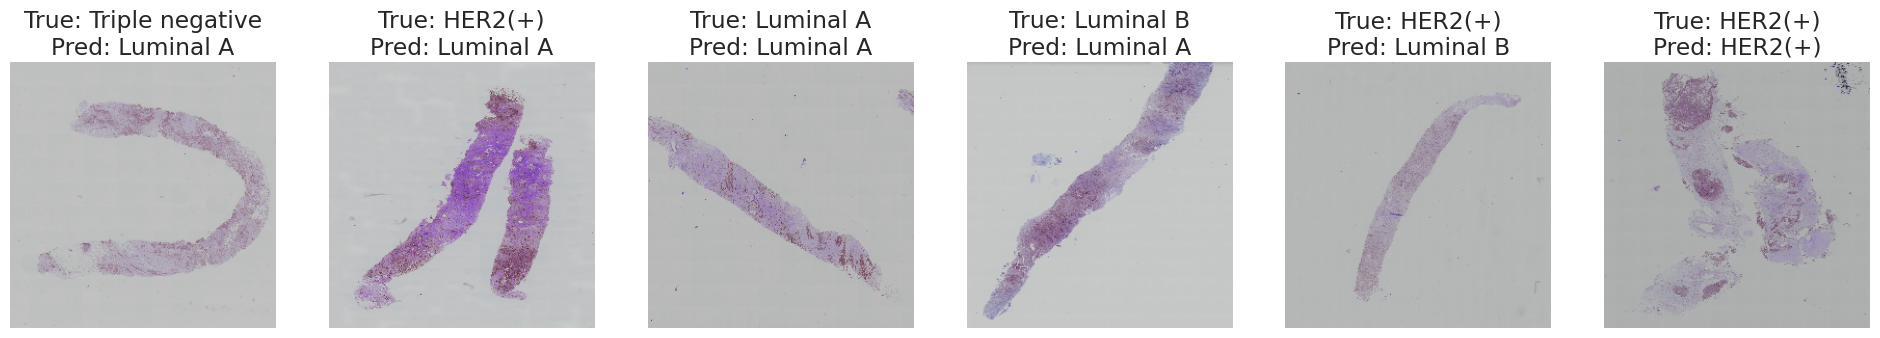

In [21]:
# Map your multitask validation arrays to the visualization function
X_val_images = X_val          # numpy array of images (H,W,C)
y_val_labels = y_val          # integer labels corresponding to class_names

visualize_classifier_predictions(
    multitask_model,
    X_val_images,
    y_val_labels,
    class_names,
    device,
    num_samples=6
)


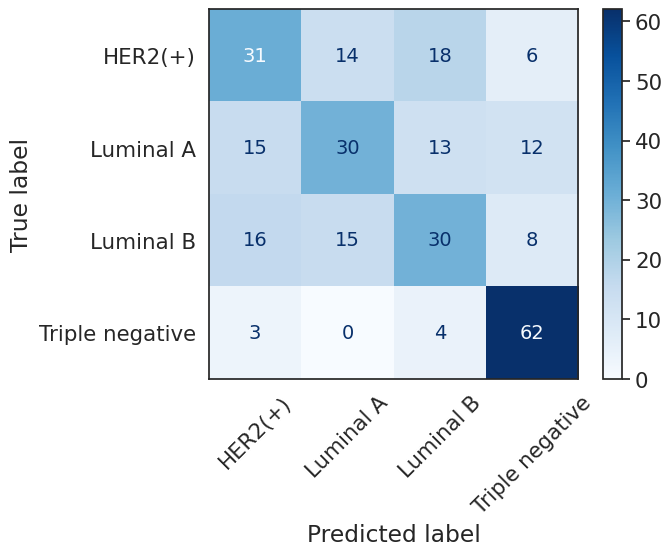

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#cls_model.eval()
multitask_model.eval()
all_preds = []
all_labels = []

for img, lbl, _ in val_mt_loader:  # unpack images, labels, boxes
    img, lbl = img.to(device), lbl.to(device)
    with torch.no_grad():
        logits, _ = multitask_model(img)  # get classification logits only
        preds = logits.argmax(dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(lbl.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.show()

In [ ]:
# Macro F1: average across classes equally
f1_macro = f1_score(all_labels, all_preds, average='macro')
print(f"Macro F1 score: {f1_macro:.4f}")

# Weighted F1: weighted by number of samples per class
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print(f"Weighted F1 score: {f1_weighted:.4f}")


                 precision    recall  f1-score   support

        HER2(+)       0.48      0.45      0.46        69
      Luminal A       0.51      0.43      0.47        70
      Luminal B       0.46      0.43      0.45        69
Triple negative       0.70      0.90      0.79        69

       accuracy                           0.55       277
      macro avg       0.54      0.55      0.54       277
   weighted avg       0.54      0.55      0.54       277



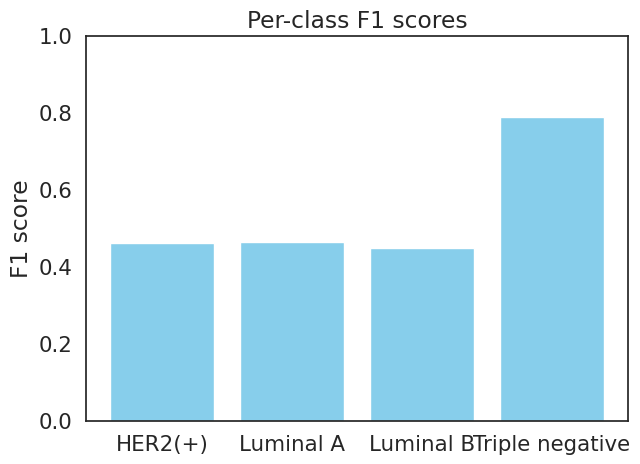

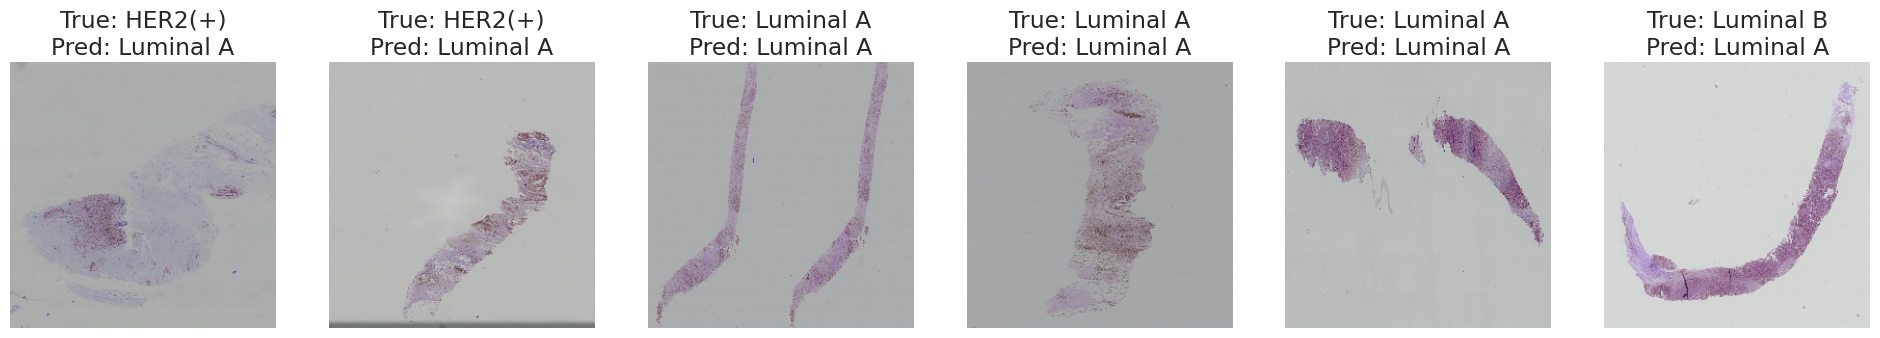

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report

# -------------------------------
# 1. Compute F1 per class
# -------------------------------
#cls_model.eval()
multitask_model.eval()
all_preds = []
all_labels = []

for img, lbl, _ in val_mt_loader:  # unpack images, labels, boxes
    img, lbl = img.to(device), lbl.to(device)
    with torch.no_grad():
        logits, _ = multitask_model(img)  # get classification logits only
        preds = logits.argmax(dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(lbl.cpu().numpy())

# Detailed classification report
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------------------
# 2. Plot per-class F1 scores
# -------------------------------
f1_scores = [report[c]['f1-score'] for c in class_names]

plt.figure(figsize=(7,5))
plt.bar(class_names, f1_scores, color='skyblue')
plt.ylabel('F1 score')
plt.title('Per-class F1 scores')
plt.ylim(0,1)
plt.show()

# -------------------------------
# 3. Visualize sample predictions
# -------------------------------
import numpy as np
import torch

def visualize_samples(model, images, labels, class_names, device, num_samples=8):
    model.eval()
    indices = np.random.choice(len(images), num_samples, replace=False)
    fig, axes = plt.subplots(2, (num_samples+1)//2, figsize=(4*((num_samples+1)//2), 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img = images[idx]
        lbl = labels[idx]
        img_tensor = torch.from_numpy(img).float().permute(2,0,1).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor).argmax(dim=1).item()
        
        axes[i].imshow(img[:,:,:3].astype(np.uint8))  # show RGB only
        axes[i].set_title(f"True: {class_names[lbl]}\nPred: {class_names[pred]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Call function
X_val_images = X_val          # numpy array of images (H,W,C)
y_val_labels = y_val          # integer labels corresponding to class_names

visualize_classifier_predictions(
    multitask_model,
    X_val_images,
    y_val_labels,
    class_names,
    device,
    num_samples=6
)


---

# TEST

In [32]:
# 15. Test set inference (classification + localisation)
# ============================================================

import torch
from torchvision import transforms
from PIL import Image
import numpy as np

def load_test_images(img_dir, img_dim):
    # only keep real images, ignore mask_XXXX.png
    files = sorted(
        [
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".tiff", ".tif", ".png", ".jpg", ".jpeg"))
            and f.startswith("img_")
        ]
    )
    images = []
    names = []
    for fname in files:
        img_path = os.path.join(img_dir, fname)
        img = cv2.imread(img_path,  cv2.IMREAD_UNCHANGED)
        
        if img is None:
            continue
            
        # # handle grayscale TIFFs (1-channel)
        # if img.ndim == 2:
        #     img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        #     print("ALARM! NDIM = 2")

        # # handle RGBA TIFFs (4-channel → RGB)
        # if img.shape[2] == 4:
        #     img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)

        # else:
        #     raise ValueError(f"Unexpected channel count: {img.shape}")


            
        # 4. Ensure always 4 channels
        assert img.shape[2] == 4, f"Expected 4 channels, got {img.shape}"
        
        img = cv2.resize(img, (img_dim, img_dim))
        
        images.append(img)
        names.append(fname)
        
    images = np.array(images)
    return images, names

# ---- Custom 4-channel transform ----
def transform_test_fn(img_np):
    # img_np: H x W x 4 (RGB + mask)
    rgb = img_np[:, :, :3]
    mask = img_np[:, :, 3]

    # Convert RGB to PIL
    rgb_pil = Image.fromarray(cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB))
    rgb_t = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])(rgb_pil)

    # Mask tensor [1,H,W]
    mask_t = torch.from_numpy(mask.astype("float32") / 255.0).unsqueeze(0)

    # Concatenate → [4,H,W]
    img_4ch = torch.cat([rgb_t, mask_t], dim=0)
    return img_4ch
    

X_test_raw, test_names = load_test_images(TEST_IMG_DIR, IMG_SIZE)
print("Loaded test images:", len(X_test_raw))

# transform_test = transforms.Compose([
#     transforms.ToImage(),
#     transforms.ToDtype(torch.float32, scale=False),
# ])

X_test_tensor = torch.stack([transform_test_fn(img) for img in X_test_raw])

# ---- Convert test images into 4-channel normalized tensor ----
# X_test_tensor = torch.stack([
#     normalize_4ch(transform_test(Image.fromarray(img)))
#     for img in X_test_raw
# ])
print("Test tensor shape:", X_test_tensor.shape)

#---------Inference-------
multitask_model.eval()


cls_probs_list = []
box_preds_list = []

BATCH_SIZE_TEST = BATCH_SIZE  # or set a specific value like 32

with torch.no_grad():
    for start in range(0, len(X_test_tensor), BATCH_SIZE_TEST):
        end = start + BATCH_SIZE_TEST
        batch = X_test_tensor[start:end].to(device)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits, boxes = multitask_model(batch)

        cls_probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
        box_preds_list.append(boxes.cpu().numpy())

cls_probs = np.concatenate(cls_probs_list, axis=0)
box_preds = np.concatenate(box_preds_list, axis=0)

print("Inference done on test set.")

Loaded test images: 954
Test tensor shape: torch.Size([954, 4, 256, 256])
Inference done on test set.


### VISUALIZE

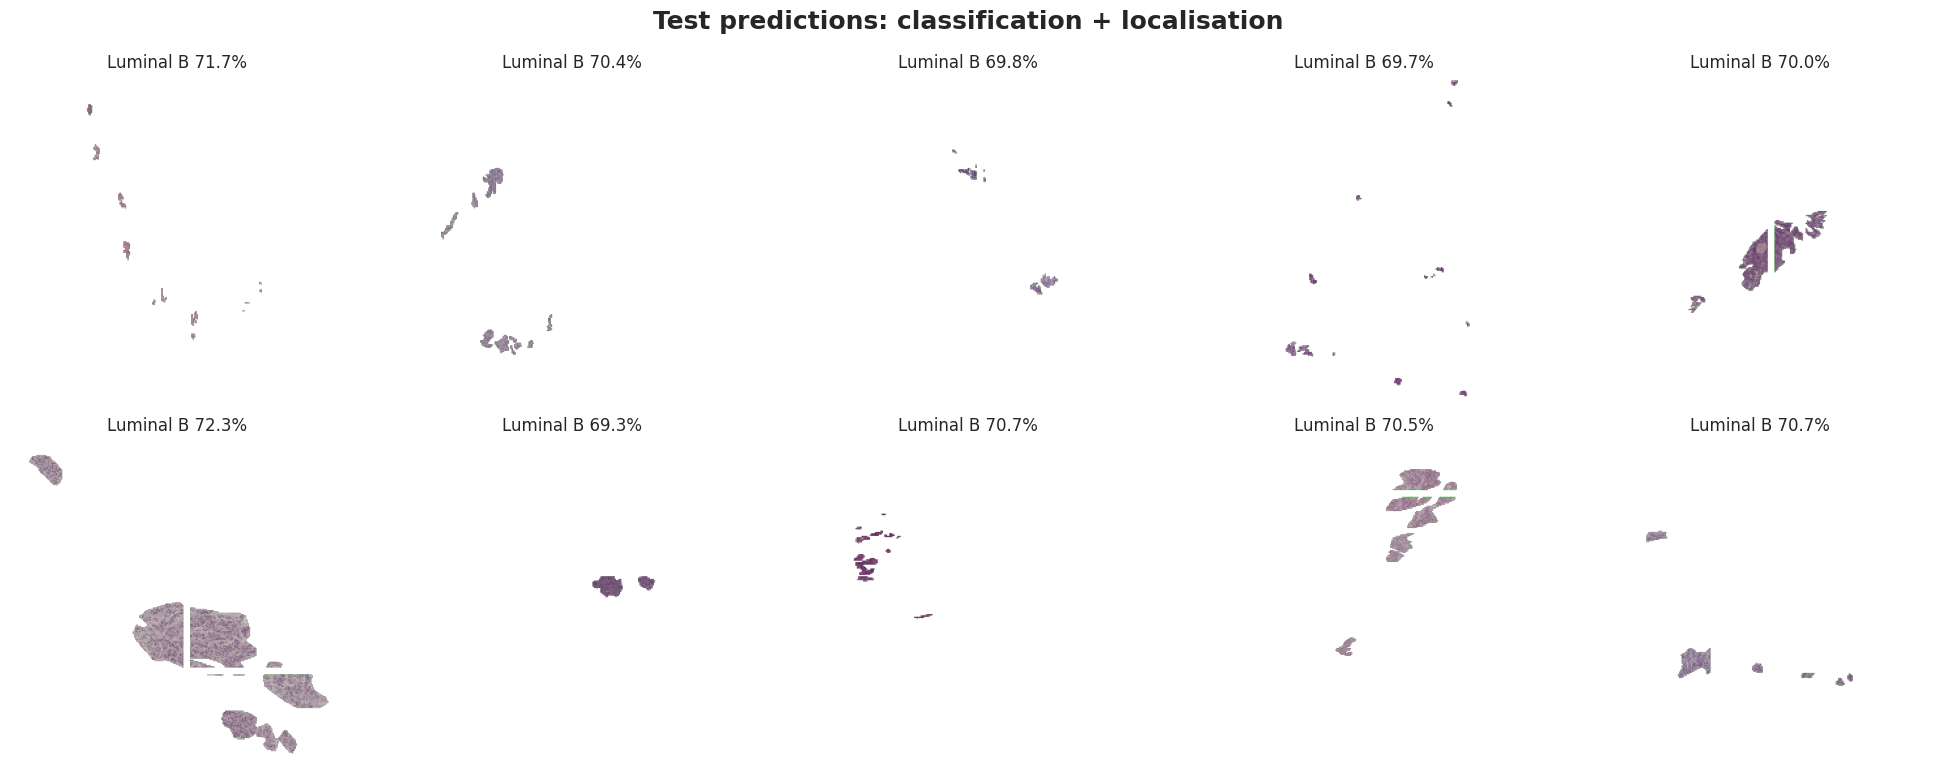

In [33]:
# ============================================================
# 16. Visualise combined predictions
# ============================================================

def visualize_test_predictions(images, cls_probs, box_preds, class_names, max_images=10):
    num_img = len(images)
    n = min(max_images, num_img)
    rows = 2
    cols = (n + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Test predictions: classification + localisation",
                 fontsize=18, fontweight="bold")

    for i in range(n):
        ax = axes[i]
        img = images[i].copy()
        h, w, _ = img.shape

        bx = box_preds[i]
        x1 = int(bx[0] * w)
        y1 = int(bx[1] * h)
        x2 = int(bx[2] * w)
        y2 = int(bx[3] * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

        lbl_idx = int(np.argmax(cls_probs[i]))
        conf = float(cls_probs[i][lbl_idx] * 100)
        lbl_name = class_names[lbl_idx]

        ax.imshow(img)
        ax.set_title(f"{lbl_name} {conf:.1f}%", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_test_predictions(X_test_raw, cls_probs, box_preds, class_names, max_images=10)

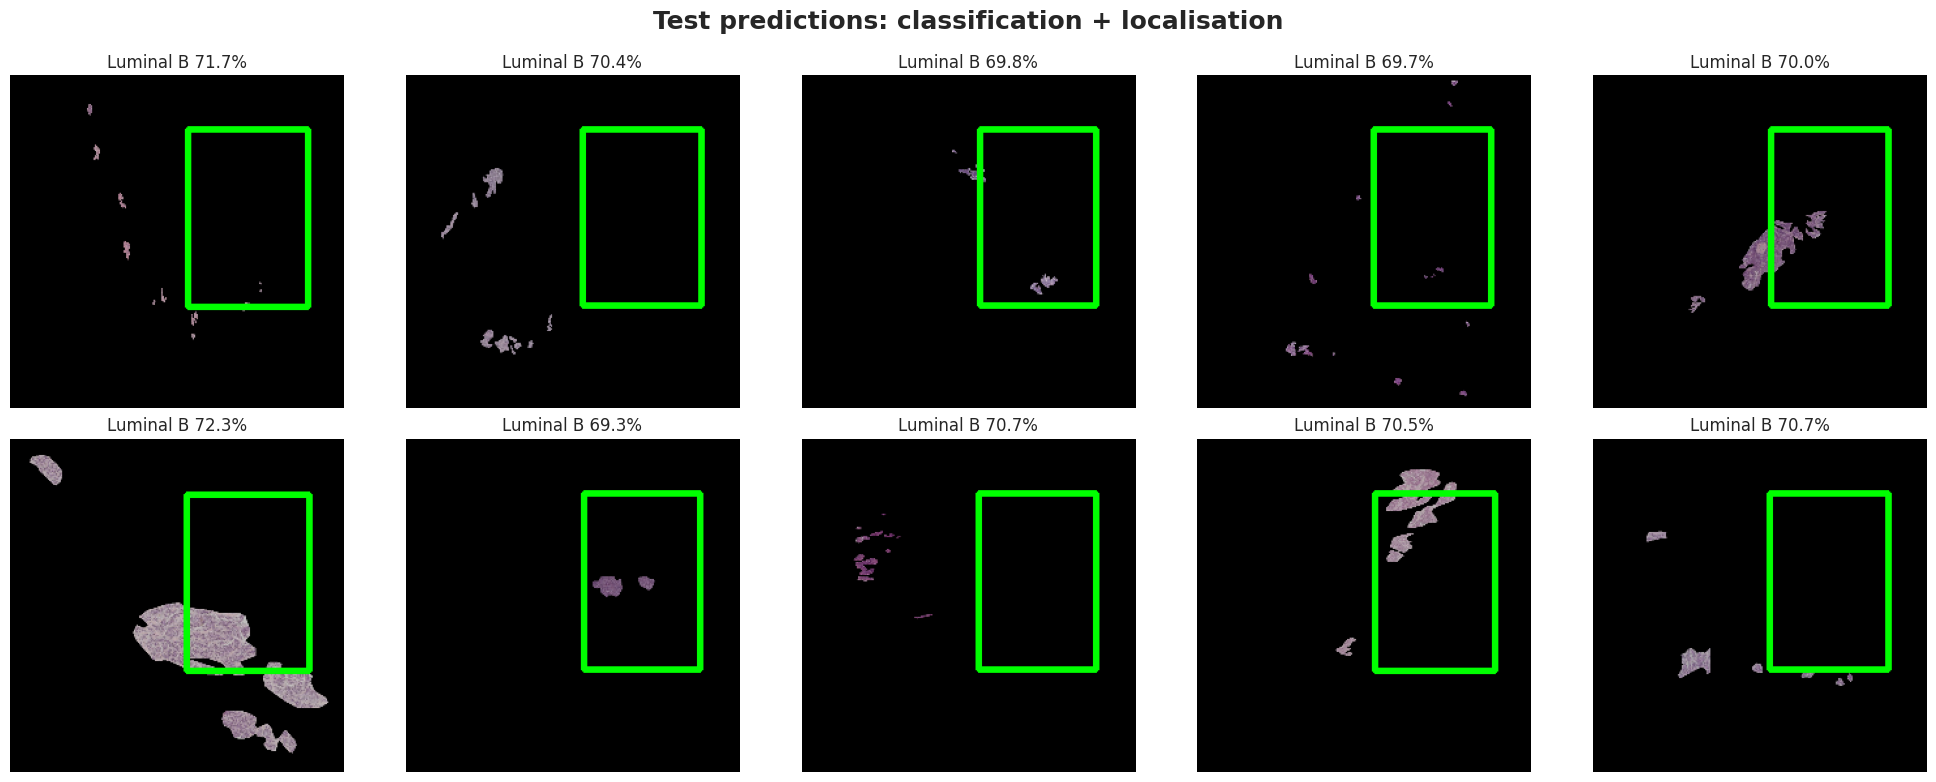

In [34]:
def visualize_test_predictions(images, cls_probs, box_preds, class_names, max_images=10):
    """
    Visualizes predictions for 4-channel TIFF images.
    The mask channel is ignored for visualization (only RGB is shown).
    """
    num_img = len(images)
    n = min(max_images, num_img)
    rows = 2
    cols = (n + 1) // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Test predictions: classification + localisation",
                 fontsize=18, fontweight="bold")

    for i in range(n):
        ax = axes[i]

        # --- handle RGBA image (H,W,4) ---
        img = images[i]

        if img.shape[2] == 4:
            rgb = img[:, :, :3]        # drop mask/alpha
        elif img.shape[2] == 3:
            rgb = img
        else:
            raise ValueError(f"Unexpected channel count: {img.shape}")

        rgb = rgb.astype(np.uint8)

        h, w, _ = rgb.shape

        # --- bounding box ---
        bx = box_preds[i]
        x1 = int(bx[0] * w)
        y1 = int(bx[1] * h)
        x2 = int(bx[2] * w)
        y2 = int(bx[3] * h)

        # Draw box
        rgb_box = rgb.copy()
        cv2.rectangle(rgb_box, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # --- classification label ---
        lbl_idx = int(np.argmax(cls_probs[i]))
        conf = float(cls_probs[i][lbl_idx] * 100)
        lbl_name = class_names[lbl_idx]

        ax.imshow(rgb_box)
        ax.set_title(f"{lbl_name} {conf:.1f}%", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_test_predictions(X_test_raw, cls_probs, box_preds, class_names, max_images=10)
print(.head())


---

# SUBMISSION

In [35]:
# Submission generation (classification)
# ============================================================

SUBMISSION_CSV = "YanaMultitask031.csv"

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # outputs float32 [0,1]
])

test_files = sorted([
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".tiff", ".png", ".jpg", ".jpeg")) and f.startswith("img_")
])

print("Number of test images used in submission:", len(test_files))

multitask_model.eval()

#cls_model.eval()
rows = []
BATCH_SIZE_SUB = 64

# Define normalize_4ch (RGB only)
normalize_4ch = T.Normalize(mean=[0.485,0.456,0.406],
                            std=[0.229,0.224,0.225])

with torch.no_grad():
    for start in range(0, len(test_files), BATCH_SIZE_SUB):
        end = start + BATCH_SIZE_SUB
        batch_files = test_files[start:end]

        batch_imgs = []
        for fname in batch_files:
            img_path = os.path.join(TEST_IMG_DIR, fname)
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

            # Handle grayscale
            if img.ndim == 2:
                img = np.stack([img]*3 + [np.zeros_like(img)], axis=-1)
                print("ndim = 2!!!")

            # Ensure 4 channels
            if img.shape[2] == 3:  # RGB → append mask
                raise ValueError(f"Expected 4 channels with mask, got 3: {fname}")
                print("ndim = 3!!!")

            elif img.shape[2] == 4:
                img = img[:, :, :4]  # RGB + mask

            # Separate RGB and mask
            rgb = img[:, :, :3]
            mask = img[:, :, 3]

            # Convert RGB to PIL and transform
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb_t = transform_test(Image.fromarray(rgb))
            rgb_t = normalize_4ch(rgb_t)

            # Resize mask to same size as RGB
            mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
            
            # Convert mask to [1,H,W] float32
            mask_t = torch.from_numpy(mask_resized.astype("float32") / 255.0).unsqueeze(0)
            
            # Concatenate RGB + mask → [4,H,W]
            img_4ch = torch.cat([rgb_t, mask_t], dim=0)

            batch_imgs.append(img_4ch)

        batch_tensor = torch.stack(batch_imgs).to(device)

        # Multitask forward
        with torch.amp.autocast(device_type=device.type, enabled=(device.type=="cuda")):
            logits, _ = multitask_model(batch_tensor)

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        labels_str = label_encoder.inverse_transform(preds)

        for fname, lab in zip(batch_files, labels_str):
            sample_name = os.path.splitext(fname)[0] + ".png"
            rows.append({"sample_index": sample_name, "label": lab})

# Save submission
sub_df = pd.DataFrame(rows)
sub_df.to_csv(SUBMISSION_CSV, index=False)

print("Saved submission to", SUBMISSION_CSV)
print(sub_df.head())
print("Submission shape:", sub_df.shape)

Number of test images used in submission: 954
Saved submission to YanaMultitask031.csv
   sample_index      label
0  img_0000.png  Luminal B
1  img_0001.png  Luminal B
2  img_0002.png  Luminal B
3  img_0003.png  Luminal B
4  img_0004.png  Luminal B
Submission shape: (954, 2)


In [ ]:
 from IPython.display import FileLink
 FileLink("YanaMultitask031.csv")